In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

dataset_path = '/content/drive/MyDrive/Finger vein enhancement/db_zvlast'
print(os.listdir(dataset_path))


['mmc', 'mmc_test', 'FVUSM', 'FVD_label', 'FVUSM_label', 'FVD', 'mmc_label', 'mmc_processed']


In [4]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import glob
import os
from pathlib import Path
import shutil
import random
import torch
from torch.utils.data import Dataset

In [48]:
class VeinDatasetCV(Dataset):
    def __init__(self, image_dir, mask_dir):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.filenames = [
            f for f in os.listdir(image_dir)
            if os.path.exists(os.path.join(mask_dir, f))
        ]

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        fname = self.filenames[idx]
        img_path = os.path.join(self.image_dir, fname)
        mask_path = os.path.join(self.mask_dir, fname)

        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        image = image.astype(np.float32) / 255.0
        mask = mask.astype(np.float32) / 255.0

        # Per-image min-max normalization (contrast normalization)
        image = (image - image.min()) / (image.max() - image.min() + 1e-8)
        mask = (mask - mask.min()) / (mask.max() - mask.min() + 1e-8)

        image = np.expand_dims(image, axis=0)
        mask = np.expand_dims(mask, axis=0)

        return torch.from_numpy(image), torch.from_numpy(mask)

In [77]:
class UnlabeledVeinDataset(Dataset):
    def __init__(self, image_dir):
        self.image_dir = image_dir
        self.filenames = [f for f in os.listdir(image_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.filenames[idx])
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE).astype(np.float32)

        # Normalize to [0,1]
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        # Convert to tensor
        img = torch.from_numpy(img).unsqueeze(0).float()  # [1,H,W]

        return img

In [78]:
from torch.utils.data import random_split, DataLoader

colab_path = "/content/drive/MyDrive/Finger vein enhancement/db_zvlast"
# Paths
label_img_dir = f"{colab_path}/mmc_label/image"
label_mask_dir = f"{colab_path}/mmc_label/mask"
unlabel_img_dir = f"{colab_path}/mmc"
test_img_dir = f"{colab_path}/mmc_test"

# --- Labeled dataset (supervised phase) ---
labeled_dataset = VeinDatasetCV(label_img_dir, label_mask_dir)

train_size = int(0.8 * len(labeled_dataset))
val_size = len(labeled_dataset) - train_size
train_ds, val_ds = random_split(labeled_dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=8, shuffle=False)

# --- Unlabeled dataset (semi-supervised phase) ---
unlabeled_dataset = UnlabeledVeinDataset(unlabel_img_dir)
unlabeled_loader = DataLoader(unlabeled_dataset, batch_size=8, shuffle=True)

# --- Test dataset (final evaluation) ---
test_dataset = UnlabeledVeinDataset(test_img_dir)
test_loader  = DataLoader(test_dataset, batch_size=8, shuffle=False)


In [79]:

for imgs, masks in train_loader:
    print("Train batch:")
    print("  Images:", imgs.shape)
    print("  Masks:", masks.shape)
    print("  Value range:", imgs.min().item(), "→", imgs.max().item())
    break

for imgs, masks in val_loader:
    print("Val batch:")
    print("  Images:", imgs.shape)
    print("  Masks:", masks.shape)
    break

for imgs in unlabeled_loader:
    print("Unlabeled batch:")
    print("  Images:", imgs.shape)
    break


Train batch:
  Images: torch.Size([8, 1, 240, 320])
  Masks: torch.Size([8, 1, 240, 320])
  Value range: 0.0 → 1.0
Val batch:
  Images: torch.Size([8, 1, 240, 320])
  Masks: torch.Size([8, 1, 240, 320])
Unlabeled batch:
  Images: torch.Size([8, 1, 240, 320])


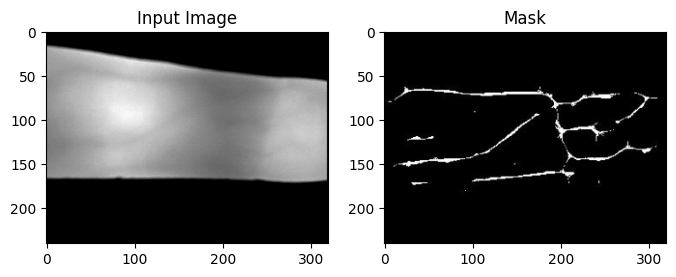

In [80]:
import matplotlib.pyplot as plt
import numpy as np

# Take one example from labeled dataset
img, mask = labeled_dataset[0]

img_np = img.squeeze().numpy()
mask_np = mask.squeeze().numpy()

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.title("Input Image")
plt.imshow(img_np, cmap='gray')

plt.subplot(1,2,2)
plt.title("Mask")
plt.imshow(mask_np, cmap='gray')
plt.show()


In [81]:
print("Labeled total:", len(labeled_dataset))
print("  Train:", len(train_ds))
print("  Val:", len(val_ds))
print("Unlabeled total:", len(unlabeled_dataset))
print("Test total:", len(test_dataset))


Labeled total: 2621
  Train: 2096
  Val: 525
Unlabeled total: 2879
Test total: 500


In [82]:
# # ORIGINAL - with fixed gabor filters
# import torch
# import torch.nn as nn
# import torch.nn.functional as F

# class AdaptiveGaborCNN(nn.Module):
#     def __init__(self, num_gabor=8, gabor_ksize=15):
#         super().__init__()
#         # Trainable Gabor layer
#         self.gabor = nn.Conv2d(1, num_gabor, kernel_size=gabor_ksize, padding=gabor_ksize//2, bias=False)

#         # Initialize Gabor kernels (optional, can start from fixed Gabor)
#         self._init_gabor()

#         # Feature extractor conv layers
#         self.conv1 = nn.Conv2d(num_gabor, 32, kernel_size=3, padding=1)
#         self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
#         self.conv3 = nn.Conv2d(64, 32, kernel_size=3, padding=1)
#         self.out_conv = nn.Conv2d(32, 1, kernel_size=1)  # final enhanced image

#     def _init_gabor(self):
#         # Optional: initialize as classical Gabor filters
#         import cv2, numpy as np
#         orientations = [0, 18, 65, 90, 115, 160]
#         ksize = self.gabor.kernel_size[0]
#         sigma, lambd, gamma, psi = 5.0, 16.0, 1, 0.0
#         kernels = []
#         for angle in orientations:
#             theta = np.deg2rad(angle)
#             kernel = cv2.getGaborKernel((ksize, ksize), sigma, theta, lambd, gamma, psi, ktype=cv2.CV_32F)
#             kernels.append(kernel)
#         kernels = np.stack(kernels, axis=0)
#         kernels = torch.from_numpy(kernels).unsqueeze(1).float()
#         with torch.no_grad():
#             self.gabor.weight[:len(kernels)] = kernels

#     # First approach
#     # def forward(self, x):
#     #     x = self.gabor(x)
#     #     x = F.relu(self.conv1(x))
#     #     x = F.relu(self.conv2(x))
#     #     x = F.relu(self.conv3(x))
#     #     x = self.out_conv(x)  # output same spatial size as input
#     #     return x

#     def forward(self, x):
#       gabor_out = self.gabor(x)
#       x1 = F.relu(self.conv1(gabor_out))
#       x2 = F.relu(self.conv2(x1))
#       x3 = F.relu(self.conv3(x2))
#       out = self.out_conv(x3 + x1)  # skip connection (preserves structure)
#       return out


In [83]:
# Adaptive gabor filter - learnable parameters
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class AdaptiveGaborCNN(nn.Module):
    def __init__(self, num_gabor=10, gabor_ksize=15):
        super().__init__()
        self.num_gabor = num_gabor
        self.gabor_ksize = gabor_ksize

        # Learnable parameters (will get gradients)
        self.sigma = nn.Parameter(torch.ones(num_gabor) * 5.0)
        self.theta = nn.Parameter(torch.tensor([0, 18, 36, 54, 72, 90, 108, 126, 144, 162]) * math.pi / 180)
        self.lambd = nn.Parameter(torch.ones(num_gabor) * 16.0)
        self.gamma = nn.Parameter(torch.ones(num_gabor) * 1.0)
        self.psi = nn.Parameter(torch.zeros(num_gabor))

        # CNN part
        self.conv1 = nn.Conv2d(num_gabor, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 32, kernel_size=3, padding=1)
        self.out_conv = nn.Conv2d(32, 1, kernel_size=1)

    def _create_gabor_bank(self):
        device = self.sigma.device
        ksize = self.gabor_ksize
        coords = torch.arange(ksize, device=device).float() - (ksize - 1) / 2
        y, x = torch.meshgrid(coords, coords, indexing='ij')

        x = x.unsqueeze(0)
        y = y.unsqueeze(0)

        # compute kernels vectorized for all filters
        x_theta = x * torch.cos(self.theta).unsqueeze(-1).unsqueeze(-1) + \
                  y * torch.sin(self.theta).unsqueeze(-1).unsqueeze(-1)
        y_theta = -x * torch.sin(self.theta).unsqueeze(-1).unsqueeze(-1) + \
                   y * torch.cos(self.theta).unsqueeze(-1).unsqueeze(-1)

        gb = torch.exp(-0.5 * ((x_theta ** 2 + (self.gamma.unsqueeze(-1).unsqueeze(-1) * y_theta) ** 2) /
                               (self.sigma.unsqueeze(-1).unsqueeze(-1) ** 2)))
        gb = gb * torch.cos(2 * math.pi * x_theta / self.lambd.unsqueeze(-1).unsqueeze(-1) +
                            self.psi.unsqueeze(-1).unsqueeze(-1))

        return gb.unsqueeze(1)  # shape: (num_gabor, 1, k, k)

    def forward(self, x):
        gabor_kernels = self._create_gabor_bank()
        gabor_out = F.conv2d(x, gabor_kernels, padding=self.gabor_ksize // 2)
        x1 = F.relu(self.conv1(gabor_out))
        x2 = F.relu(self.conv2(x1))
        x3 = F.relu(self.conv3(x2))
        return self.out_conv(x3 + x1)

In [84]:
from torch.utils.data import DataLoader

train_loader = DataLoader(labeled_dataset, batch_size=4, shuffle=True)
unlabel_loader = DataLoader(unlabeled_dataset, batch_size=4, shuffle=True)

In [85]:
class DiceBCELoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth
        self.bce = nn.BCEWithLogitsLoss()  # includes sigmoid internally

    def forward(self, logits, targets):
        # Apply sigmoid to logits
        probs = torch.sigmoid(logits)
        targets = targets.float()

        intersection = (probs * targets).sum(dim=(1,2,3))
        dice = (2. * intersection + self.smooth) / (probs.sum(dim=(1,2,3)) + targets.sum(dim=(1,2,3)) + self.smooth)
        dice_loss = 1 - dice

        bce_loss = self.bce(logits, targets)
        return (bce_loss + dice_loss.mean()) / 2


In [89]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = AdaptiveGaborCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
# optimizer = torch.optim.Adam([
#     {'params': model.gabor.parameters(), 'lr': 1e-4},
#     {'params': list(model.conv1.parameters()) + list(model.conv2.parameters()) +
#                list(model.conv3.parameters()) + list(model.out_conv.parameters()), 'lr': 1e-3}
# ])
criterion = DiceBCELoss()

In [90]:
import torch
import torch.nn.functional as F

# Edge-Preserving / Gradient Consistency Loss
def edge_preserving_loss(preds, imgs):
    # Compute Sobel gradients for both image and prediction
    sobel_x = torch.tensor([[1, 0, -1],
                            [2, 0, -2],
                            [1, 0, -1]], dtype=torch.float32, device=preds.device).unsqueeze(0).unsqueeze(0)
    sobel_y = sobel_x.transpose(2, 3)

    def grad_map(x):
        gx = F.conv2d(x, sobel_x, padding=1)
        gy = F.conv2d(x, sobel_y, padding=1)
        return torch.sqrt(gx ** 2 + gy ** 2 + 1e-6)

    grad_pred = grad_map(preds)
    grad_img = grad_map(imgs)

    # The model should have strong gradients where input has them
    # (penalize mismatch of edge magnitude)
    return torch.mean(torch.abs(grad_pred - grad_img))


In [93]:
epochs = 10

for epoch in range(epochs):
    model.train()

    # Supervised step
    for i, (imgs, masks) in enumerate(train_loader):
        imgs, masks = imgs.to(device), masks.to(device)
        preds = model(imgs)
        loss_sup = criterion(preds, masks)

        optimizer.zero_grad()
        loss_sup.backward()
        optimizer.step()

        if i % 20 == 0:
            print(f"Epoch {epoch} | Supervised batch {i} | Loss: {loss_sup.item():.4f}")

    # Unsupervised step
    for i, imgs in enumerate(unlabel_loader):
        imgs = imgs.to(device)
        preds = model(imgs)

        loss_unsup = edge_preserving_loss(preds, imgs)

        optimizer.zero_grad()
        loss_unsup.backward()
        optimizer.step()

        if i % 20 == 0:
            print(f"Epoch {epoch} | Unsupervised batch {i} | Edge loss: {loss_unsup.item():.4f}")
        # if i % 10 == 0 and i != 0:
        #     break


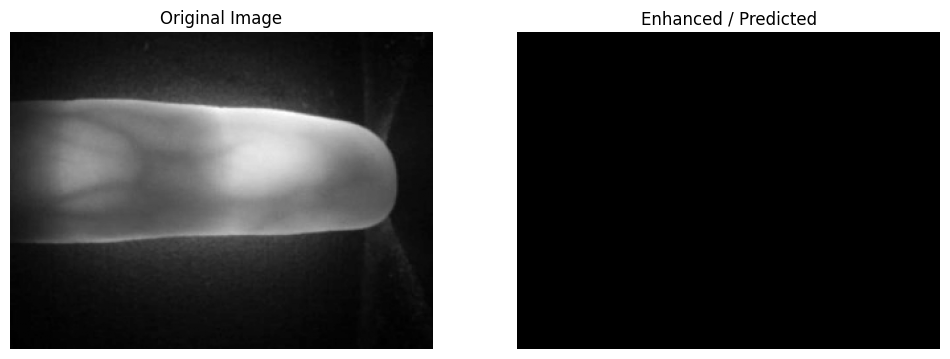

Learned Gabor parameters:
σ (sigma): [4.542 4.688 4.597 2.389 3.846 4.379 3.544 4.209 4.176 4.377]
θ (theta, deg): [  7.   18.3  36.6  39.6  48.7  63.3 142.7 138.8 147.  159.7]
λ (lambda): [15.566 15.881 16.018 15.624 15.929 15.892 15.604 15.786 15.834 15.975]
γ (gamma): [1.487 1.242 0.933 1.775 1.418 1.591 1.863 1.217 1.095 1.074]
ψ (psi): [ 0.299  0.083  0.292  0.059  0.205 -0.028 -0.404 -0.154 -0.364 -0.11 ]


In [92]:
import torch
import matplotlib.pyplot as plt
import cv2
import numpy as np

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.eval()

# --- Pick one test image ---
img_path = '/content/drive/MyDrive/Finger vein enhancement/db/test/001_08.jpg'  # or test_dataset.filenames[0] depending on your dataset
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
img_norm = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# Convert to torch tensor
input_tensor = torch.from_numpy(img_norm).unsqueeze(0).unsqueeze(0).float().to(device)  # [1,1,H,W]

# --- Forward pass ---
with torch.no_grad():
    pred = model(input_tensor)

# --- Convert output to image ---
pred_img = pred.squeeze().cpu().numpy()  # remove batch and channel dimensions
pred_img = np.clip(pred_img, 0, 255).astype(np.uint8)

# --- Display with matplotlib ---
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Enhanced / Predicted")
plt.imshow(pred_img, cmap='gray')
plt.axis('off')

plt.show()

print("Learned Gabor parameters:")
print("σ (sigma):", model.sigma.detach().cpu().numpy().round(3))
print("θ (theta, deg):", (model.theta.detach().cpu().numpy() * 180 / np.pi).round(1))
print("λ (lambda):", model.lambd.detach().cpu().numpy().round(3))
print("γ (gamma):", model.gamma.detach().cpu().numpy().round(3))
print("ψ (psi):", model.psi.detach().cpu().numpy().round(3))



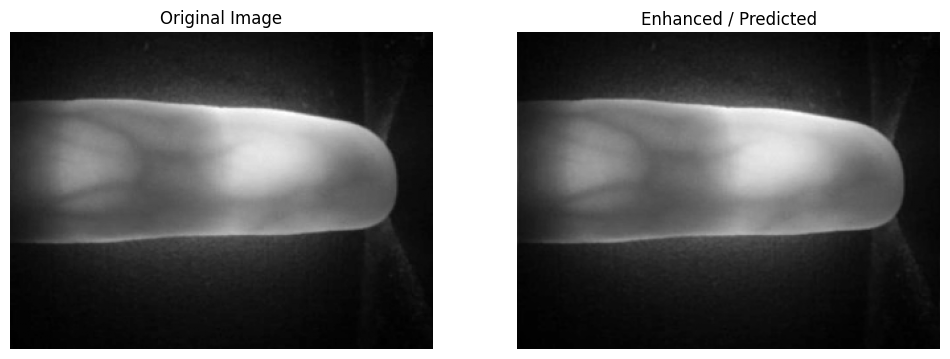

In [ ]:
import torch
import matplotlib.pyplot as plt
import cv2
import numpy as np

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.eval()

# --- Pick one test image ---
img_path = '/content/drive/MyDrive/Finger vein enhancement/db/test/001_08.jpg'  # or test_dataset.filenames[0] depending on your dataset
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
img_norm = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# Convert to torch tensor
input_tensor = torch.from_numpy(img_norm).unsqueeze(0).unsqueeze(0).float().to(device)  # [1,1,H,W]

# --- Forward pass ---
with torch.no_grad():
    pred = model(input_tensor)

# --- Convert output to image ---
pred_img = pred.squeeze().cpu().numpy()  # remove batch and channel dimensions
pred_img = np.clip(pred_img, 0, 255).astype(np.uint8)

# --- Display with matplotlib ---
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Enhanced / Predicted")
plt.imshow(pred_img, cmap='gray')
plt.axis('off')

plt.show()


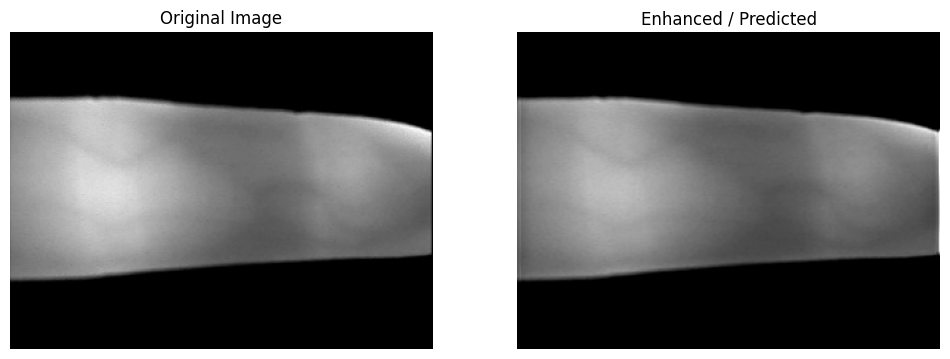

In [ ]:
import torch
import matplotlib.pyplot as plt
import cv2
import numpy as np

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.eval()

# --- Pick one test image ---
img_path = '/content/drive/MyDrive/Finger vein enhancement/db/test/001_l_08.jpg'  # or test_dataset.filenames[0] depending on your dataset
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
img_norm = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# Convert to torch tensor
input_tensor = torch.from_numpy(img_norm).unsqueeze(0).unsqueeze(0).float().to(device)  # [1,1,H,W]

# --- Forward pass ---
with torch.no_grad():
    pred = model(input_tensor)

# --- Convert output to image ---
pred_img = pred.squeeze().cpu().numpy()  # remove batch and channel dimensions
pred_img = np.clip(pred_img, 0, 255).astype(np.uint8)

# --- Display with matplotlib ---
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Enhanced / Predicted")
plt.imshow(pred_img, cmap='gray')
plt.axis('off')

plt.show()


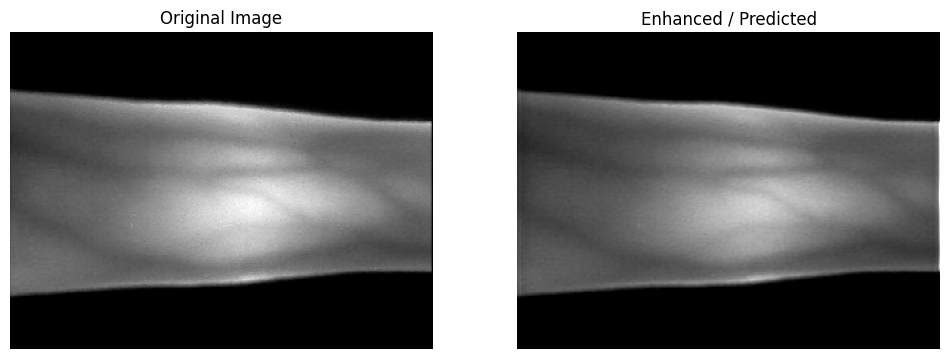

In [ ]:
import torch
import matplotlib.pyplot as plt
import cv2
import numpy as np

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.eval()

# --- Pick one test image ---
img_path = '/content/drive/MyDrive/Finger vein enhancement/db/test/002_l_18.jpg'  # or test_dataset.filenames[0] depending on your dataset
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
img_norm = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# Convert to torch tensor
input_tensor = torch.from_numpy(img_norm).unsqueeze(0).unsqueeze(0).float().to(device)  # [1,1,H,W]

# --- Forward pass ---
with torch.no_grad():
    pred = model(input_tensor)

# --- Convert output to image ---
pred_img = pred.squeeze().cpu().numpy()  # remove batch and channel dimensions
pred_img = np.clip(pred_img, 0, 255).astype(np.uint8)

# --- Display with matplotlib ---
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Enhanced / Predicted")
plt.imshow(pred_img, cmap='gray')
plt.axis('off')

plt.show()


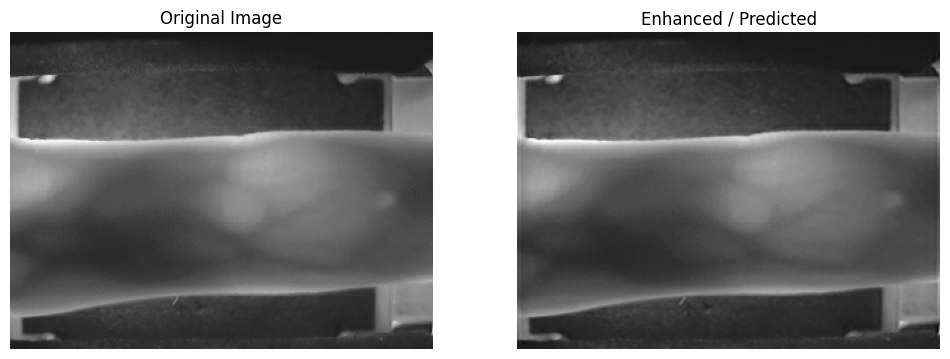

In [ ]:
import torch
import matplotlib.pyplot as plt
import cv2
import numpy as np

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.eval()

# --- Pick one test image ---
img_path = '/content/drive/MyDrive/Finger vein enhancement/db/test/002_l_ring_1.jpg'  # or test_dataset.filenames[0] depending on your dataset
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
img_norm = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# Convert to torch tensor
input_tensor = torch.from_numpy(img_norm).unsqueeze(0).unsqueeze(0).float().to(device)  # [1,1,H,W]

# --- Forward pass ---
with torch.no_grad():
    pred = model(input_tensor)

# --- Convert output to image ---
pred_img = pred.squeeze().cpu().numpy()  # remove batch and channel dimensions
pred_img = np.clip(pred_img, 0, 255).astype(np.uint8)

# --- Display with matplotlib ---
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Enhanced / Predicted")
plt.imshow(pred_img, cmap='gray')
plt.axis('off')

plt.show()
